# NBA Stats Database
Fetches 2025-26 season stats from NBA.com and saves to a local SQLite database for SQL querying.

## 1. Install Dependencies

In [ ]:
!pip install nba_api pandas

## 2. Fetch Player Stats from NBA.com

In [1]:
from nba_api.stats.endpoints import leaguedashplayerstats, leaguedashteamstats
import pandas as pd
import sqlite3

SEASON = '2025-26'

# --- Player Stats ---
print('Fetching player stats...')
player_stats = leaguedashplayerstats.LeagueDashPlayerStats(season=SEASON)
df_players = pd.DataFrame(player_stats.get_data_frames()[0])
print(f'Players fetched: {len(df_players)}')
df_players.head()

Fetching player stats...
Players fetched: 582


,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,...,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,TEAM_COUNT
0,1630639,A.J. Lawson,A.J.,1610612761,TOR,25.0,24,12,12,0.500,...,125,142,443,438,290,450,284,38,449,1
1,1631260,AJ Green,AJ,1610612749,MIL,26.0,78,31,47,0.397,...,271,540,229,126,496,175,284,38,139,1
2,1642358,AJ Johnson,AJ,1610612742,DAL,21.0,48,9,39,0.188,...,371,158,384,400,394,414,284,38,413,2
3,203932,Aaron Gordon,Aaron,1610612743,DEN,30.0,36,27,9,0.750,...,271,242,143,197,48,247,114,38,241,1
4,1628988,Aaron Holiday,Aaron,1610612745,HOU,29.0,57,38,19,0.667,...,179,274,323,321,99,354,284,38,348,1


In [2]:
# --- Team Stats ---
print('Fetching team stats...')
team_stats = leaguedashteamstats.LeagueDashTeamStats(season=SEASON)
df_teams = pd.DataFrame(team_stats.get_data_frames()[0])
print(f'Teams fetched: {len(df_teams)}')
df_teams.head()

Fetching team stats...
Teams fetched: 30


,TEAM_ID,TEAM_NAME,GP,W,L,W_PCT,MIN,FGM,FGA,FG_PCT,...,REB_RANK,AST_RANK,TOV_RANK,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK
0,1610612737,Atlanta Hawks,82,46,36,0.561,3951.0,3575,7541,0.474,...,18,1,10,5,18,17,14,26,6,12
1,1610612738,Boston Celtics,82,56,26,0.683,3946.0,3456,7398,0.467,...,3,27,1,28,11,3,9,27,19,4
2,1610612751,Brooklyn Nets,82,20,62,0.244,3951.0,3071,6933,0.443,...,30,26,29,22,23,23,26,21,30,28
3,1610612766,Charlotte Hornets,82,44,38,0.537,3951.0,3357,7292,0.460,...,5,15,25,29,21,9,10,18,13,8
4,1610612741,Chicago Bulls,82,31,51,0.378,3951.0,3476,7417,0.469,...,9,7,23,23,11,26,8,24,12,22


## 3. Save to SQLite Database

In [3]:
conn = sqlite3.connect('nba_stats.db')

df_players.to_sql('player_stats', conn, if_exists='replace', index=False)
df_teams.to_sql('team_stats', conn, if_exists='replace', index=False)

# Relational view joining players to their team stats
conn.execute('DROP VIEW IF EXISTS players_with_team')
conn.execute("""
    CREATE VIEW players_with_team AS
    SELECT
        p.PLAYER_NAME,
        p.TEAM_ABBREVIATION,
        p.GP,
        p.PTS,
        p.REB,
        p.AST,
        p.STL,
        p.BLK,
        p.FG_PCT,
        p.FG3_PCT,
        p.FT_PCT,
        t.W,
        t.L,
        t.W_PCT AS TEAM_WIN_PCT
    FROM player_stats p
    JOIN team_stats t ON p.TEAM_ABBREVIATION = t.TEAM_ABBREVIATION
""")

conn.commit()
conn.close()
print('Database saved as nba_stats.db')

Database saved as nba_stats.db


## 4. Query the Database
Run any of the queries below, or write your own SQL.

In [5]:
def query(sql):
    conn = sqlite3.connect('nba_stats.db')
    result = pd.read_sql(sql, conn)
    conn.close()
    return result

In [6]:
# Top 10 scorers
query("""
    SELECT PLAYER_NAME, TEAM_ABBREVIATION, PTS, REB, AST
    FROM player_stats
    ORDER BY PTS DESC
    LIMIT 10
""")

,PLAYER_NAME,TEAM_ABBREVIATION,PTS,REB,AST
0,Luka Dončić,LAL,2143,495,530
1,Shai Gilgeous-Alexander,OKC,2117,292,448
2,Jaylen Brown,BOS,2038,492,364
3,Kevin Durant,HOU,2026,426,372
4,Tyrese Maxey,PHI,1980,290,461
5,Donovan Mitchell,CLE,1952,316,398
6,Jalen Brunson,NYK,1927,247,503
7,Jamal Murray,DEN,1905,330,535
8,Kawhi Leonard,LAC,1813,413,234
9,Nikola Jokić,DEN,1799,836,697


In [5]:
import ollama

from ollama import chat
from ollama import ChatResponse
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import json


DB_PATH = "nba_stats.db"
model = 'gemma4'

In [4]:
def get_schema():
    conn = sqlite3.connect(DB_PATH)
    schema = conn.execute(
        "SELECT sql FROM sqlite_master WHERE type='table'"
    ).fetchall()
    conn.close()
    return "\n".join([s[0] for s in schema if s[0]])

In [7]:
# --- Step 3: Run the SQL ---
def run_query(sql):
    conn = sqlite3.connect(DB_PATH)
    df = pd.read_sql(sql, conn)
    conn.close()
    return df

In [12]:
# ask another agent
def get_visualization_code(df, stat_name, stat_description):
    prompt = f"""You are a data visualization expert.

I have this pandas DataFrame called 'df' with columns: {df.columns.tolist()}
Here is a sample of the data:
{df.head(10).to_string()}

The stat being visualized is: {stat_name} — {stat_description}

Write Python matplotlib code to visualize this. Follow these rules strictly:
1. Use plt.figure(figsize=(14, 7))
2. Add a main title with the stat name
3. Add a subtitle using plt.suptitle or fig.text showing the formula/description: "{stat_description}"
4. Rotate x-axis labels 45 degrees with ha='right' to avoid overlap
5. Use plt.subplots_adjust(bottom=0.25) to give x labels room
6. Add value labels on top of each bar
7. Make it look clean with a tight layout
Return ONLY executable Python code, no explanations, no markdown backticks."""

    response = chat(model=model, messages=[{'role': 'user', 'content': prompt}])
    return response.message.content.strip()

In [9]:
def invent_stat_and_query(user_question):
    schema = get_schema()
    prompt = f"""You are an NBA statistician with access to this SQLite database schema:

{schema}

The user wants to know: "{user_question}"

Your job:
1. Invent a meaningful custom statistic (like QBR, PER, etc.) as a formula using the available columns
2. Write a SQL query that computes it as a new column using arithmetic on existing columns
3. Return ONLY a JSON object in this exact format, no other text:

{{
    "stat_name": "NAME_OF_YOUR_STAT",
    "stat_description": "Brief explanation of what the stat measures",
    "sql": "SELECT PLAYER_NAME, TEAM_ABBREVIATION, ROUND(formula, 2) AS stat_name FROM player_stats WHERE GP >= 20 ORDER BY stat_name DESC LIMIT 15"
}}"""

    response = chat(model=model, messages=[{'role': 'user', 'content': prompt}])
    raw = response.message.content.strip()

    # Strip markdown code fences if present
    if raw.startswith("```"):
        raw = raw.split("```")[1]
        if raw.startswith("json"):
            raw = raw[4:]

    return json.loads(raw.strip())

In [10]:
# --- Main pipeline ---
def analyze(question):
    print(f"\nQuestion: {question}")
    print("Inventing stat and generating SQL...")

    result = invent_stat_and_query(question)
    print(f"\nStat: {result['stat_name']}")
    print(f"Description: {result['stat_description']}")
    print(f"SQL: {result['sql']}")

    df = run_query(result['sql'])
    print(f"\nResults ({len(df)} rows):")
    print(df.head())

    print("\nGenerating visualization...")
    viz_code = get_visualization_code(df, result['stat_name'], result['stat_description'])

    # Execute the visualization
    exec(viz_code, {"df": df, "plt": plt, "pd": pd})
    plt.tight_layout()
    plt.show()

# --- Try it ---
analyze("Who are the most complete two-way players this season?")


Question: Who are the most complete two-way players this season?
Inventing stat and generating SQL...


KeyboardInterrupt: 


Question: make metric for best defense adjusted for height, my goal is to find a way to look at defensive school as opposed to just physical talent.
Inventing stat and generating SQL...

Stat: Adjusted Defensive Value (ADV)
Description: Measures the combined defensive impact (Steals, Blocks, and Defensive Rebounds) per minute of play. By normalizing these disruptive defensive actions by minutes, it attempts to quantify a player's consistent defensive 'school' or scheme presence, rather than relying solely on physical talent or total accumulated stats.
SQL: SELECT PLAYER_NAME, TEAM_ABBREVIATION, ROUND((CAST(STL AS REAL) * 1.5 + CAST(BLK AS REAL) * 1.5 + CAST(DREB AS REAL) * 1.0) / NULLIF(MIN, 0), 2) AS "Adjusted Defensive Value" FROM player_stats WHERE GP >= 20 ORDER BY "Adjusted Defensive Value" DESC LIMIT 15

Results (15 rows):
           PLAYER_NAME TEAM_ABBREVIATION  Adjusted Defensive Value
0    Victor Wembanyama               SAS                      0.54
1  Robert Williams III  

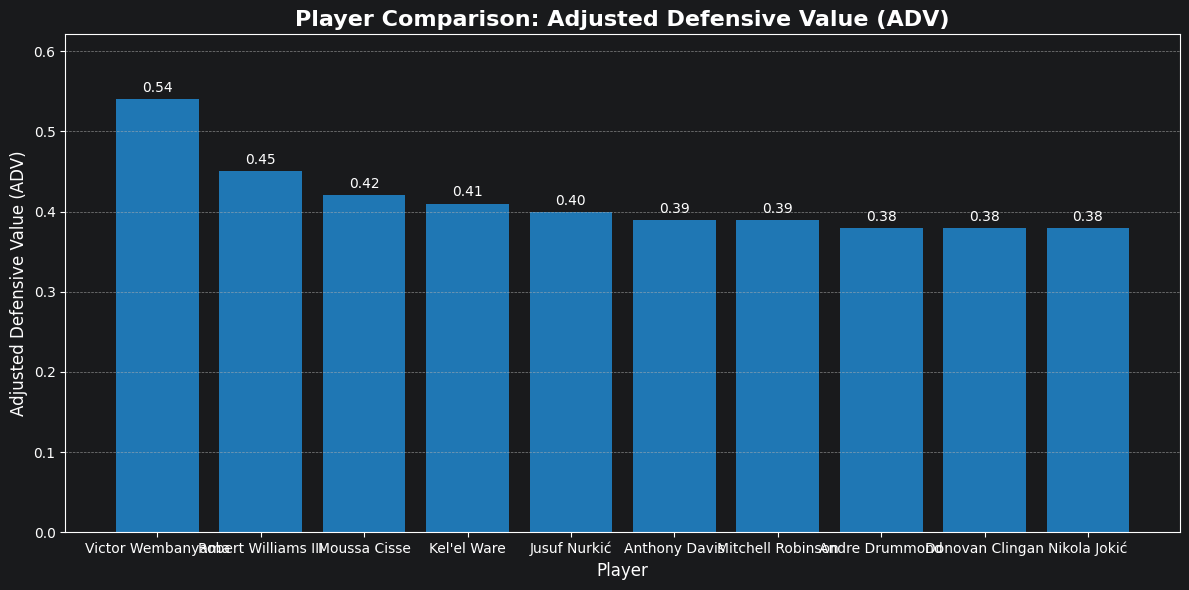

<Figure size 640x480 with 0 Axes>

In [11]:
if __name__ == "__main__":
    question = input("Ask a question: ")
    analyze(question)